# 05 — SWC 形态简化 (Persistence-based Pruning)

将 FAFB connectome 中 95K 视觉神经元的 SWC 形态进行拓扑简化，
输出简化后的 SWC 文件，保留 **xyz 坐标 + 半径 + 树结构**，
用于后续加载到 multi-compartment HH network。

### 简化算法（参考 `simplify_neurons.py`）

1. **Collinear merging** — 合并近似直线上的冗余采样点（角度阈值 5°）
2. **Persistence pruning** — 按叶分支的“持久值”排序，保留 top `keep_ratio` 的分支
3. 输出标准 SWC 格式 `id type x y z r parent`

### 流程

1. 测试不同 `keep_ratio` (0.02 / 0.05 / 0.10 / 0.20)，选择合适参数
2. 按 **neuron type** 分批简化，少于 10 个 neuron 的 type 合并处理
3. 简化后的 SWC 存到 `mcHH/data/simplified_swc/`
4. 每处理 100 个 neuron 输出一条进度信息


In [1]:
import sys, os, time, zipfile, math, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, '../..')
sys.setrecursionlimit(100000)

## 1. 配置

In [2]:
FAFB_ZIP = '/Users/lengyuner/Desktop/data/flywire/Jun2025/sk_lod1_783_healed.zip'
T4T5_DIR = '/Users/lengyuner/Desktop/Ripple/data/T4T5/swc_microns'
VNT_PATH = '/Users/lengyuner/Desktop/data/flywire/Jun2025/visual_neuron_types.csv.gz'

OUT_DIR = Path('/Users/lengyuner/Desktop/NIPS2026/mcHH/data/simplified_swc')
OUT_DIR.mkdir(parents=True, exist_ok=True)

KEEP_RATIO = 0.05
COLLINEAR_ANGLE_DEG = 5.0

print(f'Output dir : {OUT_DIR}')
print(f'keep_ratio : {KEEP_RATIO}  ({(1-KEEP_RATIO)*100:.0f}% pruning)')
print(f'collinear  : {COLLINEAR_ANGLE_DEG}°')

Output dir : /Users/lengyuner/Desktop/NIPS2026/mcHH/data/simplified_swc
keep_ratio : 0.05  (95% pruning)
collinear  : 5.0°


## 2. 加载神经元列表 & 打开 SWC zip

In [3]:
vnt = pd.read_csv(VNT_PATH)
print(f'Visual neurons: {len(vnt):,},  types: {vnt["type"].nunique()}')

zf = zipfile.ZipFile(FAFB_ZIP, 'r')
zip_name_set = set(zf.namelist())
zip_ids = set()
for name in zip_name_set:
    if name.endswith('.swc'):
        try:
            zip_ids.add(int(name.replace('.swc', '').split('/')[-1]))
        except ValueError:
            pass
print(f'SWC in zip : {len(zip_ids):,}')

local_ids = set()
if os.path.isdir(T4T5_DIR):
    for f in os.listdir(T4T5_DIR):
        if f.endswith('.swc'):
            local_ids.add(int(f.replace('.swc', '')))
print(f'Local T4T5 : {len(local_ids)}')

vnt['has_swc'] = vnt['root_id'].isin(zip_ids | local_ids)
print(f'With SWC   : {vnt["has_swc"].sum():,} / {len(vnt):,}')

Visual neurons: 95,079,  types: 741
SWC in zip : 139,273
Local T4T5 : 395
With SWC   : 95,079 / 95,079


## 3. 简化核心函数

与 `simplify_neurons.py` 算法一致：

- `load_swc` → 解析 SWC，构建树
- `simplify_collinear_nodes` → 几何合并直线节点
- `compute_distances / max_subtree / persistence` → 持久性分析
- `prune_tree` → 保留 top-k 分支
- `write_swc` → 输出标准 SWC

In [4]:
def load_swc(filepath):
    nodes = {}
    with open(filepath) as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            nid = int(parts[0])
            nodes[nid] = {
                'id': nid, 'type': int(parts[1]),
                'x': float(parts[2]), 'y': float(parts[3]), 'z': float(parts[4]),
                'r': float(parts[5]), 'parent': int(parts[6]),
                'children': []
            }
    for nid, node in nodes.items():
        pid = node['parent']
        if pid != -1 and pid in nodes:
            nodes[pid]['children'].append(nid)
    roots = [nid for nid, n in nodes.items() if n['parent'] == -1]
    root = roots[0] if roots else (1 if 1 in nodes else min(nodes.keys()))
    return nodes, root


def compute_distances(nodes, root):
    dist = {root: 0.0}
    stack = [root]
    while stack:
        nid = stack.pop()
        for cid in nodes[nid]['children']:
            if cid not in nodes:
                continue
            dx = nodes[nid]['x'] - nodes[cid]['x']
            dy = nodes[nid]['y'] - nodes[cid]['y']
            dz = nodes[nid]['z'] - nodes[cid]['z']
            dist[cid] = dist[nid] + math.sqrt(dx*dx + dy*dy + dz*dz)
            stack.append(cid)
    return dist


def compute_max_subtree_dist(nodes, root, dist):
    max_dist = {}
    stack = [root]
    visit_order = []
    while stack:
        nid = stack.pop()
        visit_order.append(nid)
        for cid in nodes[nid]['children']:
            if cid in nodes:
                stack.append(cid)
    for nid in reversed(visit_order):
        m = dist.get(nid, 0.0)
        for cid in nodes[nid]['children']:
            if cid in nodes and cid in max_dist:
                m = max(m, max_dist[cid])
        max_dist[nid] = m
    return max_dist


def compute_branch_persistence(nodes, root, dist, max_dist):
    branches = []
    for nid, node in nodes.items():
        if node['children']:
            continue
        leaf = nid
        current = leaf
        s = -1
        while True:
            parent = nodes[current]['parent']
            if parent == -1:
                s = parent; break
            if parent not in nodes:
                s = -1; break
            siblings = [c for c in nodes[parent]['children']
                        if c != current and c in nodes and c in max_dist]
            if any(max_dist.get(sib, 0) > dist.get(leaf, 0) for sib in siblings):
                s = parent; break
            current = parent
        persistence = dist.get(leaf, 0) - dist.get(s, 0) if s != -1 else dist.get(leaf, 0)
        branches.append((leaf, s, persistence))
    branches.sort(key=lambda x: -x[2])
    return branches


def prune_tree(nodes, branches, keep_ratio):
    keep_set = set()
    n_keep = max(1, int(len(branches) * keep_ratio))
    for leaf, s, _ in branches[:n_keep]:
        current = leaf
        while current != s and current != -1:
            keep_set.add(current)
            if current not in nodes:
                break
            current = nodes[current]['parent']
        if s != -1:
            keep_set.add(s)
    for nid, n in nodes.items():
        if n['parent'] == -1:
            keep_set.add(nid)
    new_nodes = {nid: n.copy() for nid, n in nodes.items() if nid in keep_set}
    for nid in list(new_nodes):
        node = new_nodes[nid]
        if node['parent'] not in new_nodes:
            node['parent'] = -1
        node['children'] = [c for c in node['children'] if c in new_nodes]
    return new_nodes


def simplify_collinear_nodes(nodes, angle_threshold_degrees=5.0, min_seg=1e-6):
    while True:
        children_map = {nid: [] for nid in nodes}
        for nid, node in nodes.items():
            pid = node['parent']
            if pid != -1 and pid in nodes:
                children_map[pid].append(nid)
        to_remove = []
        for nid, node in nodes.items():
            pid = node['parent']
            if pid == -1 or pid not in nodes:
                continue
            ch = children_map.get(nid, [])
            if len(ch) != 1:
                continue
            cid = ch[0]
            if cid not in nodes:
                continue
            p = np.array([nodes[pid]['x'], nodes[pid]['y'], nodes[pid]['z']])
            a = np.array([node['x'], node['y'], node['z']])
            c = np.array([nodes[cid]['x'], nodes[cid]['y'], nodes[cid]['z']])
            v1, v2 = p - a, c - a
            l1, l2 = np.linalg.norm(v1), np.linalg.norm(v2)
            if l1 < min_seg or l2 < min_seg:
                continue
            cos_a = np.clip(np.dot(v1, v2) / (l1 * l2), -1.0, 1.0)
            if cos_a <= -math.cos(math.radians(angle_threshold_degrees)):
                to_remove.append((nid, pid, cid))
        if not to_remove:
            break
        for nid, pid, cid in to_remove:
            if nid in nodes and cid in nodes and pid in nodes:
                nodes[cid]['parent'] = pid
                del nodes[nid]
    return nodes


def write_swc(nodes, out_path):
    with open(out_path, 'w') as f:
        f.write('# Simplified SWC (persistence pruning)\n')
        f.write('# id type x y z r parent\n')
        for nid in sorted(nodes):
            n = nodes[nid]
            f.write(f"{n['id']} {n['type']} {n['x']:.4f} {n['y']:.4f} "
                    f"{n['z']:.4f} {n['r']:.4f} {n['parent']}\n")


def read_swc_text(root_id, zf, zip_name_set, local_dir):
    """Read SWC text from local dir or zip."""
    name = f'{root_id}.swc'
    if local_dir and os.path.isfile(os.path.join(local_dir, name)):
        with open(os.path.join(local_dir, name)) as f:
            return f.read()
    if name in zip_name_set:
        return zf.read(name).decode('utf-8', errors='replace')
    return None


def simplify_one(swc_text, keep_ratio, collinear_angle):
    """Full pipeline: SWC text -> (simplified_nodes, orig_count, simp_count)"""
    with tempfile.NamedTemporaryFile(suffix='.swc', mode='w', delete=False) as tmp:
        tmp.write(swc_text)
        tmp_path = tmp.name
    try:
        nodes, root = load_swc(tmp_path)
    finally:
        os.unlink(tmp_path)
    if len(nodes) < 3:
        return nodes, len(nodes), len(nodes)
    orig = len(nodes)
    nodes = simplify_collinear_nodes(nodes, angle_threshold_degrees=collinear_angle)
    dist = compute_distances(nodes, root)
    max_dist = compute_max_subtree_dist(nodes, root, dist)
    branches = compute_branch_persistence(nodes, root, dist, max_dist)
    final = prune_tree(nodes, branches, keep_ratio=keep_ratio)
    return final, orig, len(final)


print('Functions defined.')

Functions defined.


## 4. 测试不同 keep_ratio

在几种关键 neuron type 上对比不同简化程度，确认 `keep_ratio=0.05` 是否合理。

In [5]:
test_types = ['R1-6', 'L1', 'Mi1', 'Tm3', 'T4a', 'T5a']
test_ratios = [0.02, 0.05, 0.10, 0.20]

test_neurons = {}
for ct in test_types:
    row = vnt[(vnt['type'] == ct) & vnt['has_swc']]
    if len(row) > 0:
        rid = row['root_id'].iloc[0]
        txt = read_swc_text(rid, zf, zip_name_set, T4T5_DIR)
        if txt:
            test_neurons[ct] = (rid, txt)

print(f'Test neurons: {list(test_neurons.keys())}')

results = {}
header = f'{"Type":>6s}  {"Orig":>6s}'
for r in test_ratios:
    header += f'  keep={r:<5}'
print(f'\n{header}')
print('-' * 65)

for ct, (rid, txt) in test_neurons.items():
    row_results = {}
    _, orig, _ = simplify_one(txt, 1.0, COLLINEAR_ANGLE_DEG)
    line = f'{ct:>6s}  {orig:6d}'
    for r in test_ratios:
        nodes, _, simp = simplify_one(txt, r, COLLINEAR_ANGLE_DEG)
        row_results[r] = (simp, nodes)
        line += f'  {simp:6d}   '
    print(line)
    results[ct] = (orig, row_results)

Test neurons: ['R1-6', 'L1', 'Mi1', 'Tm3', 'T4a', 'T5a']

  Type    Orig  keep=0.02   keep=0.05   keep=0.1    keep=0.2  
-----------------------------------------------------------------
  R1-6     596      97        140        179        227   
    L1    1689     325        354        407        570   
   Mi1    2079     605        680        728        853   
   Tm3    2797    1010       1031       1080       1294   
   T4a    2103     629        654        700        790   
   T5a    1947     445        476        522        726   


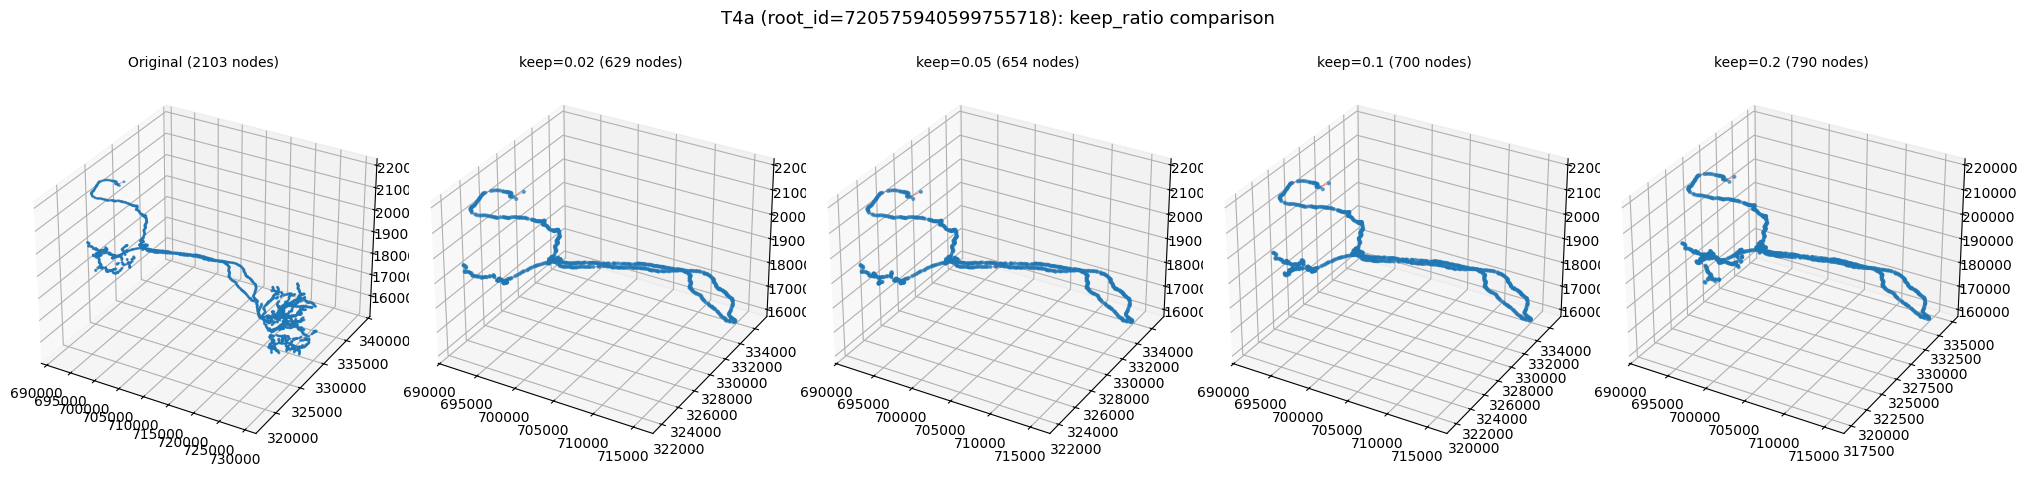

In [6]:
demo_type = 'T4a' if 'T4a' in results else list(results.keys())[0]
orig_count, ratio_results = results[demo_type]
rid, txt = test_neurons[demo_type]

with tempfile.NamedTemporaryFile(suffix='.swc', mode='w', delete=False) as tmp:
    tmp.write(txt); tp = tmp.name
orig_nodes, _ = load_swc(tp)
os.unlink(tp)

fig = plt.figure(figsize=(20, 5))
panels = [('Original', orig_nodes)] + [(f'keep={r}', ratio_results[r][1]) for r in test_ratios]

for i, (title, nd) in enumerate(panels):
    ax = fig.add_subplot(1, len(panels), i+1, projection='3d')
    xs = [n['x'] for n in nd.values()]
    ys = [n['y'] for n in nd.values()]
    zs = [n['z'] for n in nd.values()]
    for nid, n in nd.items():
        if n['parent'] != -1 and n['parent'] in nd:
            p = nd[n['parent']]
            ax.plot([n['x'], p['x']], [n['y'], p['y']], [n['z'], p['z']],
                    'b-' if i == 0 else 'r-', lw=0.5, alpha=0.5)
    ax.scatter(xs, ys, zs, s=1 if i == 0 else 4, alpha=0.6)
    ax.set_title(f'{title} ({len(nd)} nodes)', fontsize=10)

fig.suptitle(f'{demo_type} (root_id={rid}): keep_ratio comparison', fontsize=13)
plt.tight_layout(); plt.show()

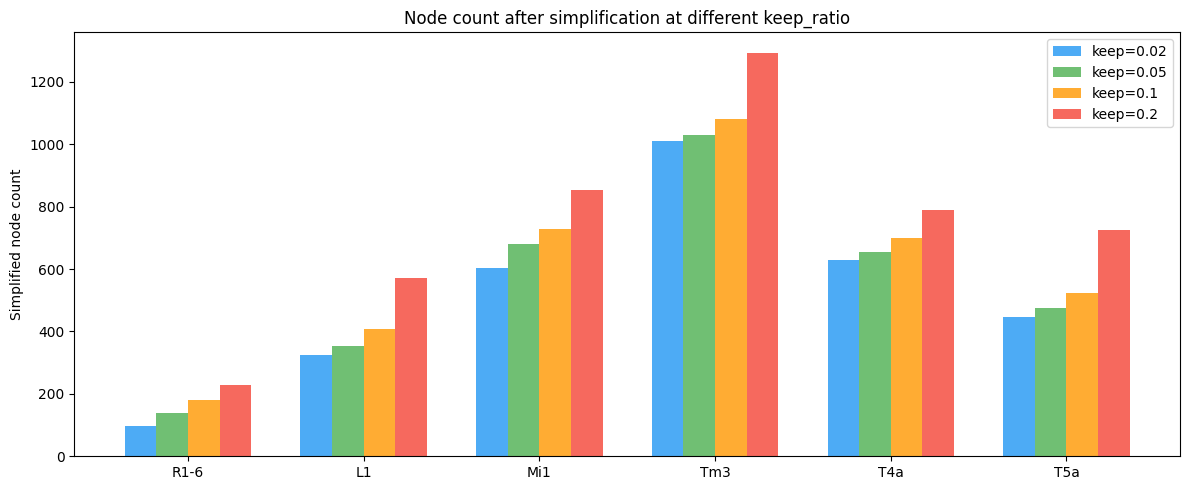


keep_ratio=0.05 在保留主要结构的同时大幅减少节点数，适合 multi-compartment HH 仿真。


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(results))
width = 0.18
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

type_names = list(results.keys())
for j, r in enumerate(test_ratios):
    vals = [results[ct][1][r][0] for ct in type_names]
    ax.bar(x_pos + j * width, vals, width, label=f'keep={r}', color=colors[j], alpha=0.8)

ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels(type_names)
ax.set_ylabel('Simplified node count')
ax.set_title('Node count after simplification at different keep_ratio')
ax.legend()
plt.tight_layout(); plt.show()

print('\nkeep_ratio=0.05 在保留主要结构的同时大幅减少节点数，'
      '适合 multi-compartment HH 仿真。')

## 5. 验证 Jaxley / MorphologyGraph 兼容性

确认简化后的 SWC 保留 xyz 坐标，能被 Jaxley 和 MorphologyGraph 正确加载。

In [9]:
demo_rid, demo_txt = test_neurons[demo_type]
demo_nodes, demo_orig, demo_simp = simplify_one(demo_txt, KEEP_RATIO, COLLINEAR_ANGLE_DEG)
test_path = OUT_DIR / f'{demo_rid}.swc'
write_swc(demo_nodes, test_path)

print(f'Written: {test_path}')
print(f'  {demo_orig} -> {demo_simp} nodes ({(1-demo_simp/demo_orig)*100:.1f}% reduction)')

print(f'\nSample nodes (xyz + r preserved):')
for nid in sorted(demo_nodes.keys())[:5]:
    n = demo_nodes[nid]
    print(f'  id={n["id"]:4d}  x={n["x"]:12.2f}  y={n["y"]:12.2f}  '
          f'z={n["z"]:12.2f}  r={n["r"]:8.4f}  parent={n["parent"]}')

import warnings; warnings.filterwarnings('ignore')
try:
    import jaxley as jx
    cell = jx.read_swc(str(test_path), ncomp=1)
    print(f'\nJaxley OK: {len(cell.nodes)} branches')
    print(f'  X: [{cell.nodes["x"].min():.1f}, {cell.nodes["x"].max():.1f}]')
    print(f'  Y: [{cell.nodes["y"].min():.1f}, {cell.nodes["y"].max():.1f}]')
    print(f'  Z: [{cell.nodes["z"].min():.1f}, {cell.nodes["z"].max():.1f}]')
    print(f'  Radius: [{cell.nodes["radius"].min():.4f}, {cell.nodes["radius"].max():.4f}]')
except ImportError:
    print('\nJaxley not available')
except Exception as e:
    print(f'\nJaxley error: {e}')

from neuro_framework.models.morphology import MorphologyGraph
morph = MorphologyGraph.from_swc(str(test_path), ncomp=1)
print(f'\nMorphologyGraph OK: n_comp={morph.n_comp}, n_branches={morph.n_branches}')
warnings.filterwarnings('default')

Written: /Users/lengyuner/Desktop/NIPS2026/mcHH/data/simplified_swc/720575940599755718.swc
  2103 -> 654 nodes (68.9% reduction)

Sample nodes (xyz + r preserved):
  id=   1  x=   696037.10  y=   324885.40  z=   217919.69  r=1471.0000  parent=-1
  id=   2  x=   691581.60  y=   322658.97  z=   194025.67  r= 91.0000  parent=3
  id=   3  x=   691685.30  y=   322628.78  z=   194036.60  r= 72.0000  parent=4
  id=   4  x=   691848.25  y=   322604.94  z=   194099.38  r=146.0000  parent=7
  id=   5  x=   692076.90  y=   323261.72  z=   215360.94  r=184.0000  parent=9

Jaxley OK: 1 branches
  X: [696037.1, 696037.1]
  Y: [324885.4, 324885.4]
  Z: [217919.7, 217919.7]
  Radius: [1471.0000, 1471.0000]

MorphologyGraph OK: n_comp=1, n_branches=1


## 6. 按 neuron type 分批简化全部 95K 神经元

策略：
- 按 `type` 分组，每种 type 作为一个 batch
- neuron 数少于 10 的 type 合并为 `_rare_batch_N`
- 已存在的 SWC 文件跳过（支持断点续传）
- 每处理 100 个 neuron 打印一条进度信息
- 每个 batch 完成后 append 汇总到 `_summary.csv`

In [10]:
neurons_with_swc = vnt[vnt['has_swc']].copy()
type_counts = neurons_with_swc['type'].value_counts()

big_types = type_counts[type_counts >= 10].index.tolist()
rare_types = type_counts[type_counts < 10].index.tolist()
rare_total = type_counts[type_counts < 10].sum()

print(f'Types >= 10 neurons : {len(big_types)}  '
      f'({type_counts[type_counts >= 10].sum():,} neurons)')
print(f'Rare types (< 10)   : {len(rare_types)}  ({rare_total:,} neurons)')

batches = []
for ct in big_types:
    ids = neurons_with_swc[neurons_with_swc['type'] == ct]['root_id'].tolist()
    batches.append((ct, ids))

rare_ids = neurons_with_swc[
    neurons_with_swc['type'].isin(rare_types)
]['root_id'].tolist()
RARE_BATCH_SIZE = 100
for i in range(0, len(rare_ids), RARE_BATCH_SIZE):
    chunk = rare_ids[i:i + RARE_BATCH_SIZE]
    batches.append((f'_rare_{i // RARE_BATCH_SIZE}', chunk))

total_neurons = sum(len(ids) for _, ids in batches)
print(f'\nTotal batches : {len(batches)}')
print(f'Total neurons : {total_neurons:,}')

Types >= 10 neurons : 298  (93,842 neurons)
Rare types (< 10)   : 443  (1,237 neurons)

Total batches : 311
Total neurons : 95,079


In [11]:
id_to_type = vnt.set_index('root_id')['type'].to_dict()
summary_path = OUT_DIR / '_summary.csv'

existing_ids = set()
if summary_path.exists():
    existing_df = pd.read_csv(summary_path)
    existing_ids = set(existing_df['root_id'].values)
    print(f'Existing summary: {len(existing_ids):,} neurons already done')

global_t0 = time.time()
global_done = 0
global_skip = 0
global_fail = 0
new_records = []

for batch_i, (batch_name, id_list) in enumerate(batches):
    batch_t0 = time.time()
    batch_done = 0
    batch_skip = 0
    batch_fail = 0

    for rid in id_list:
        out_path = OUT_DIR / f'{rid}.swc'

        if rid in existing_ids or out_path.exists():
            batch_skip += 1
            global_skip += 1
            global_done += 1
            continue

        swc_text = read_swc_text(rid, zf, zip_name_set, T4T5_DIR)
        if swc_text is None:
            batch_fail += 1
            global_fail += 1
            global_done += 1
            continue

        try:
            simplified, orig_n, simp_n = simplify_one(
                swc_text, KEEP_RATIO, COLLINEAR_ANGLE_DEG)
            write_swc(simplified, out_path)
            new_records.append({
                'root_id': rid,
                'type': id_to_type.get(rid, ''),
                'original_nodes': orig_n,
                'simplified_nodes': simp_n,
                'keep_ratio': KEEP_RATIO,
            })
            batch_done += 1
        except Exception as e:
            batch_fail += 1
            global_fail += 1

        global_done += 1

        if global_done % 100 == 0:
            elapsed = time.time() - global_t0
            speed = global_done / elapsed
            remaining = (total_neurons - global_done) / max(speed, 0.01)
            print(f'  [{global_done:6,d}/{total_neurons:,}]  '
                  f'{elapsed/60:5.1f}min elapsed, '
                  f'{remaining/60:5.1f}min remain, '
                  f'{speed:.1f} n/s')

    batch_elapsed = time.time() - batch_t0
    print(f'Batch {batch_i+1:3d}/{len(batches)}  '
          f'{batch_name:>20s}  '
          f'done={batch_done:4d}  skip={batch_skip:4d}  fail={batch_fail:2d}  '
          f'{batch_elapsed:.1f}s')

    if new_records:
        new_df = pd.DataFrame(new_records)
        if summary_path.exists():
            old = pd.read_csv(summary_path)
            combined = pd.concat([old, new_df], ignore_index=True)
        else:
            combined = new_df
        combined.to_csv(summary_path, index=False)
        new_records = []

total_elapsed = time.time() - global_t0
print(f'\n===== DONE =====')
print(f'Total: {global_done:,} neurons  |  '
      f'skip={global_skip:,}  fail={global_fail}  |  '
      f'{total_elapsed/60:.1f} min')

  [   100/95,079]    0.0min elapsed,  20.7min remain, 76.3 n/s
  [   200/95,079]    0.0min elapsed,  22.1min remain, 71.7 n/s
  [   300/95,079]    0.1min elapsed,  22.0min remain, 71.7 n/s
  [   400/95,079]    0.1min elapsed,  21.4min remain, 73.6 n/s
  [   500/95,079]    0.1min elapsed,  20.7min remain, 76.3 n/s
  [   600/95,079]    0.1min elapsed,  20.5min remain, 76.7 n/s
  [   700/95,079]    0.2min elapsed,  20.4min remain, 77.1 n/s
  [   800/95,079]    0.2min elapsed,  20.1min remain, 78.3 n/s
  [   900/95,079]    0.2min elapsed,  20.2min remain, 77.6 n/s
  [ 1,000/95,079]    0.2min elapsed,  20.3min remain, 77.3 n/s
  [ 1,100/95,079]    0.2min elapsed,  20.6min remain, 76.2 n/s
  [ 1,200/95,079]    0.3min elapsed,  20.8min remain, 75.2 n/s
  [ 1,300/95,079]    0.3min elapsed,  20.8min remain, 75.2 n/s
  [ 1,400/95,079]    0.3min elapsed,  20.7min remain, 75.5 n/s
  [ 1,500/95,079]    0.3min elapsed,  20.5min remain, 75.9 n/s
  [ 1,600/95,079]    0.3min elapsed,  20.4min remain, 7

## 7. 验证输出

In [12]:
saved_swc = list(OUT_DIR.glob('*.swc'))
print(f'Simplified SWC files: {len(saved_swc):,}')

if summary_path.exists():
    sdf = pd.read_csv(summary_path)
    print(f'Summary CSV rows : {len(sdf):,}')
    pct = (1 - sdf['simplified_nodes'] / sdf['original_nodes'].clip(lower=1)) * 100
    print(f'\nCompression stats (keep_ratio={KEEP_RATIO}):')
    print(f'  Original  : mean={sdf["original_nodes"].mean():.0f}, '
          f'median={sdf["original_nodes"].median():.0f}')
    print(f'  Simplified: mean={sdf["simplified_nodes"].mean():.0f}, '
          f'median={sdf["simplified_nodes"].median():.0f}')
    print(f'  Compression: mean={pct.mean():.1f}%, median={pct.median():.1f}%')

    show = ['R1-6', 'L1', 'L3', 'L5', 'Mi1', 'Mi9', 'Tm3', 'T4a', 'T5a']
    print(f'\n{"Type":>6s}  {"Count":>6s}  {"Orig":>8s}  {"Simp":>8s}  {"Ratio":>6s}')
    print('-' * 42)
    for ct in show:
        sub = sdf[sdf['type'] == ct]
        if len(sub) == 0:
            continue
        print(f'{ct:>6s}  {len(sub):6d}  {sub["original_nodes"].mean():8.0f}  '
              f'{sub["simplified_nodes"].mean():8.0f}  '
              f'{sub["simplified_nodes"].mean()/sub["original_nodes"].mean()*100:5.1f}%')

Simplified SWC files: 95,079
Summary CSV rows : 95,078

Compression stats (keep_ratio=0.05):
  Original  : mean=3557, median=2385
  Simplified: mean=703, median=581
  Compression: mean=77.5%, median=78.8%

  Type   Count      Orig      Simp   Ratio
------------------------------------------
  R1-6    7172       751       121   16.1%
    L1    1627      1603       303   18.9%
    L3    1430      1852       398   21.5%
    L5    1580      1936       525   27.1%
   Mi1    1581      2263       475   21.0%
   Mi9    1551      2318       520   22.4%
   Tm3    1755      2472       639   25.8%
   T4a    1456      2060       565   27.4%
   T5a    1483      1778       464   26.1%


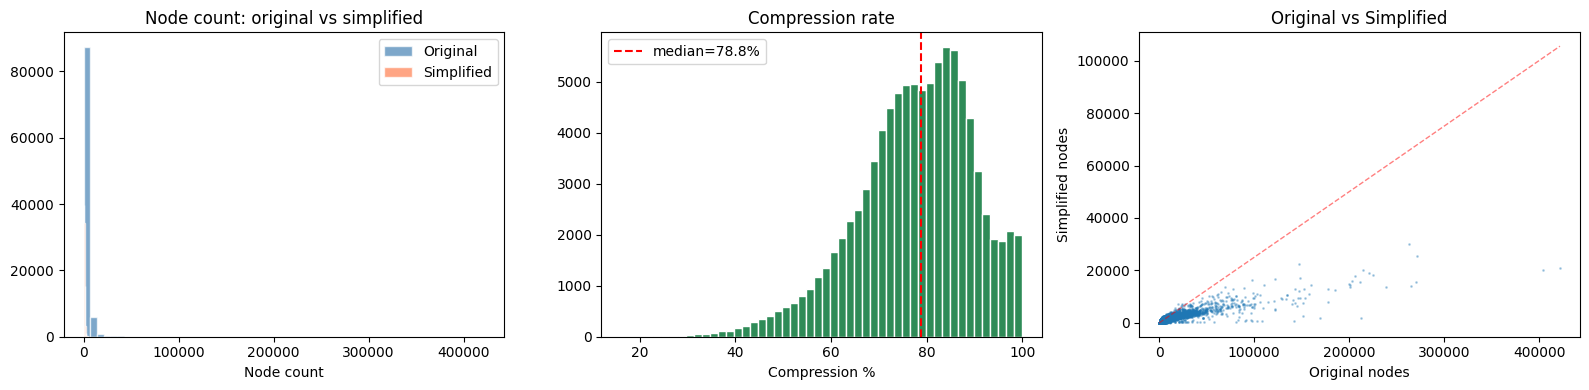

In [13]:
if summary_path.exists():
    sdf = pd.read_csv(summary_path)
    pct = (1 - sdf['simplified_nodes'] / sdf['original_nodes'].clip(lower=1)) * 100

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].hist(sdf['original_nodes'], bins=60, color='steelblue',
                 edgecolor='white', alpha=0.7, label='Original')
    axes[0].hist(sdf['simplified_nodes'], bins=60, color='coral',
                 edgecolor='white', alpha=0.7, label='Simplified')
    axes[0].set_xlabel('Node count')
    axes[0].set_title('Node count: original vs simplified')
    axes[0].legend()

    axes[1].hist(pct, bins=50, color='seagreen', edgecolor='white')
    axes[1].axvline(pct.median(), color='red', ls='--',
                     label=f'median={pct.median():.1f}%')
    axes[1].set_xlabel('Compression %')
    axes[1].set_title('Compression rate')
    axes[1].legend()

    axes[2].scatter(sdf['original_nodes'], sdf['simplified_nodes'],
                    s=1, alpha=0.3)
    axes[2].plot([0, sdf['original_nodes'].max()],
                 [0, sdf['original_nodes'].max() * KEEP_RATIO * 5],
                 'r--', lw=1, alpha=0.5)
    axes[2].set_xlabel('Original nodes')
    axes[2].set_ylabel('Simplified nodes')
    axes[2].set_title('Original vs Simplified')

    plt.tight_layout(); plt.show()

## 8. 抽样 3D 可视化: 各类型简化前后对比

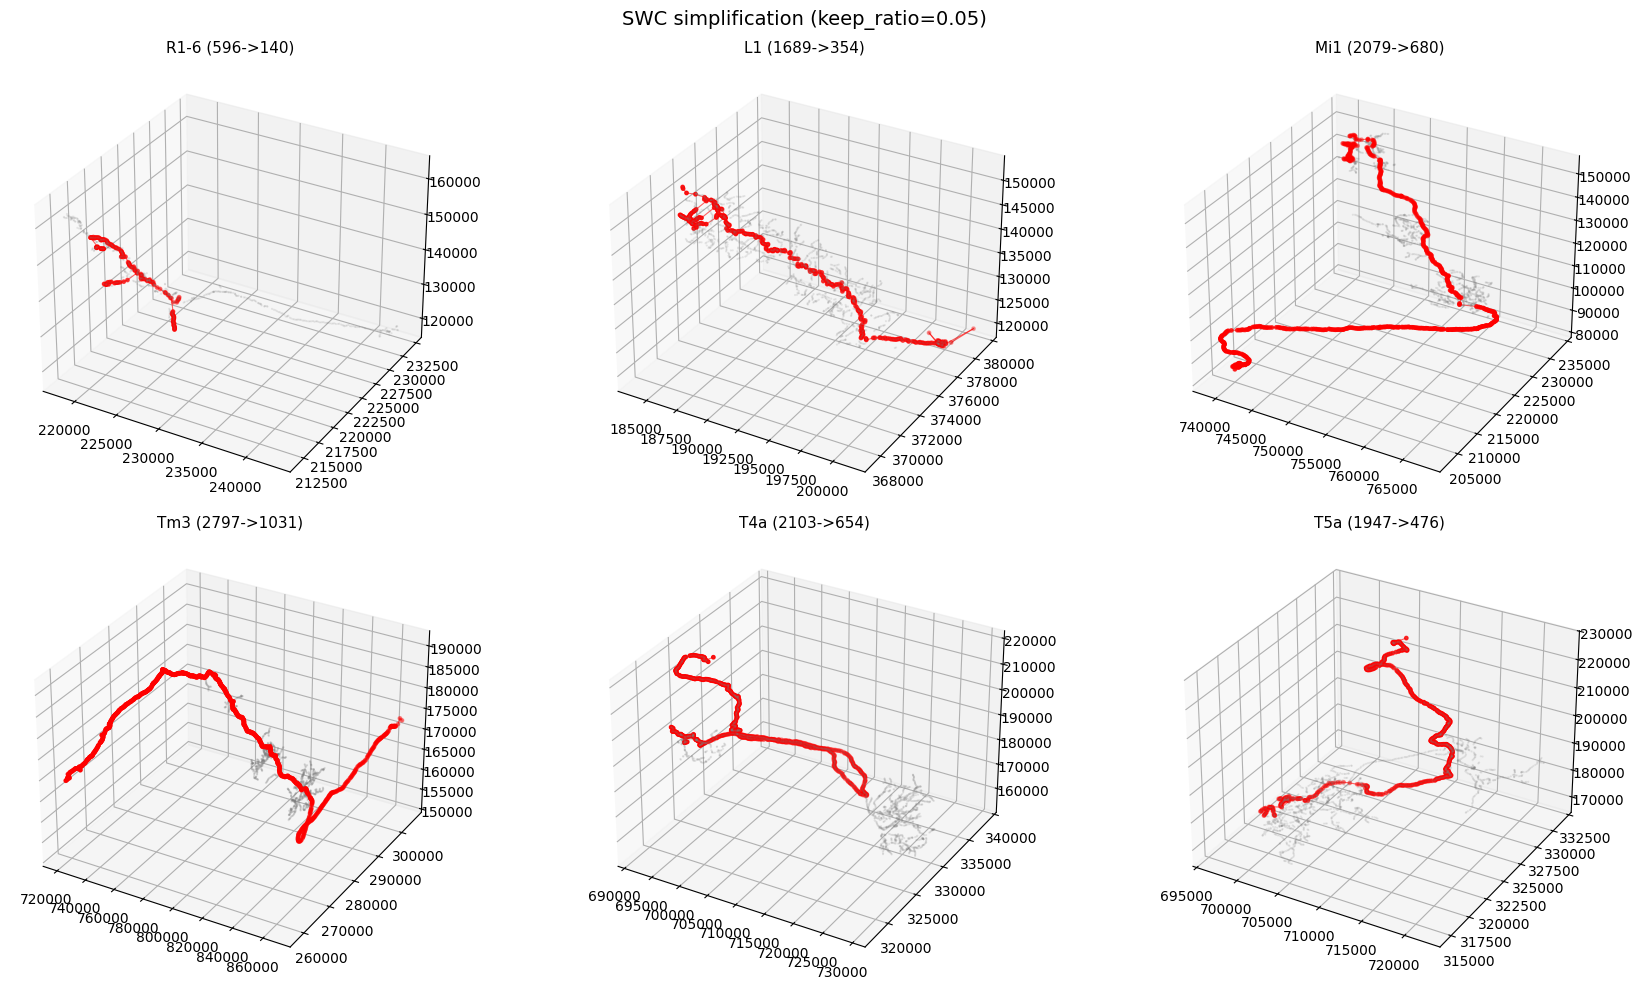

In [14]:
show_types = ['R1-6', 'L1', 'Mi1', 'Tm3', 'T4a', 'T5a']

fig = plt.figure(figsize=(18, 10))
for i, ct in enumerate(show_types):
    sample = vnt[(vnt['type'] == ct) & vnt['has_swc']]
    if len(sample) == 0:
        continue
    rid = sample['root_id'].iloc[0]

    txt = read_swc_text(rid, zf, zip_name_set, T4T5_DIR)
    if txt is None:
        continue
    with tempfile.NamedTemporaryFile(suffix='.swc', mode='w', delete=False) as tmp:
        tmp.write(txt); tp = tmp.name
    orig, _ = load_swc(tp)
    os.unlink(tp)

    simp_path = OUT_DIR / f'{rid}.swc'
    if simp_path.exists():
        simp, _ = load_swc(str(simp_path))
    else:
        simp, _, _ = simplify_one(txt, KEEP_RATIO, COLLINEAR_ANGLE_DEG)

    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    ox = [n['x'] for n in orig.values()]
    oy = [n['y'] for n in orig.values()]
    oz = [n['z'] for n in orig.values()]
    ax.scatter(ox, oy, oz, s=0.3, alpha=0.15, c='gray')

    for nid, n in simp.items():
        if n['parent'] != -1 and n['parent'] in simp:
            p = simp[n['parent']]
            ax.plot([n['x'], p['x']], [n['y'], p['y']], [n['z'], p['z']],
                    'r-', lw=0.8, alpha=0.6)
    sx = [n['x'] for n in simp.values()]
    sy = [n['y'] for n in simp.values()]
    sz = [n['z'] for n in simp.values()]
    ax.scatter(sx, sy, sz, s=6, c='red')
    ax.set_title(f'{ct} ({len(orig)}->{len(simp)})', fontsize=11)

fig.suptitle(f'SWC simplification (keep_ratio={KEEP_RATIO})', fontsize=14)
plt.tight_layout(); plt.show()

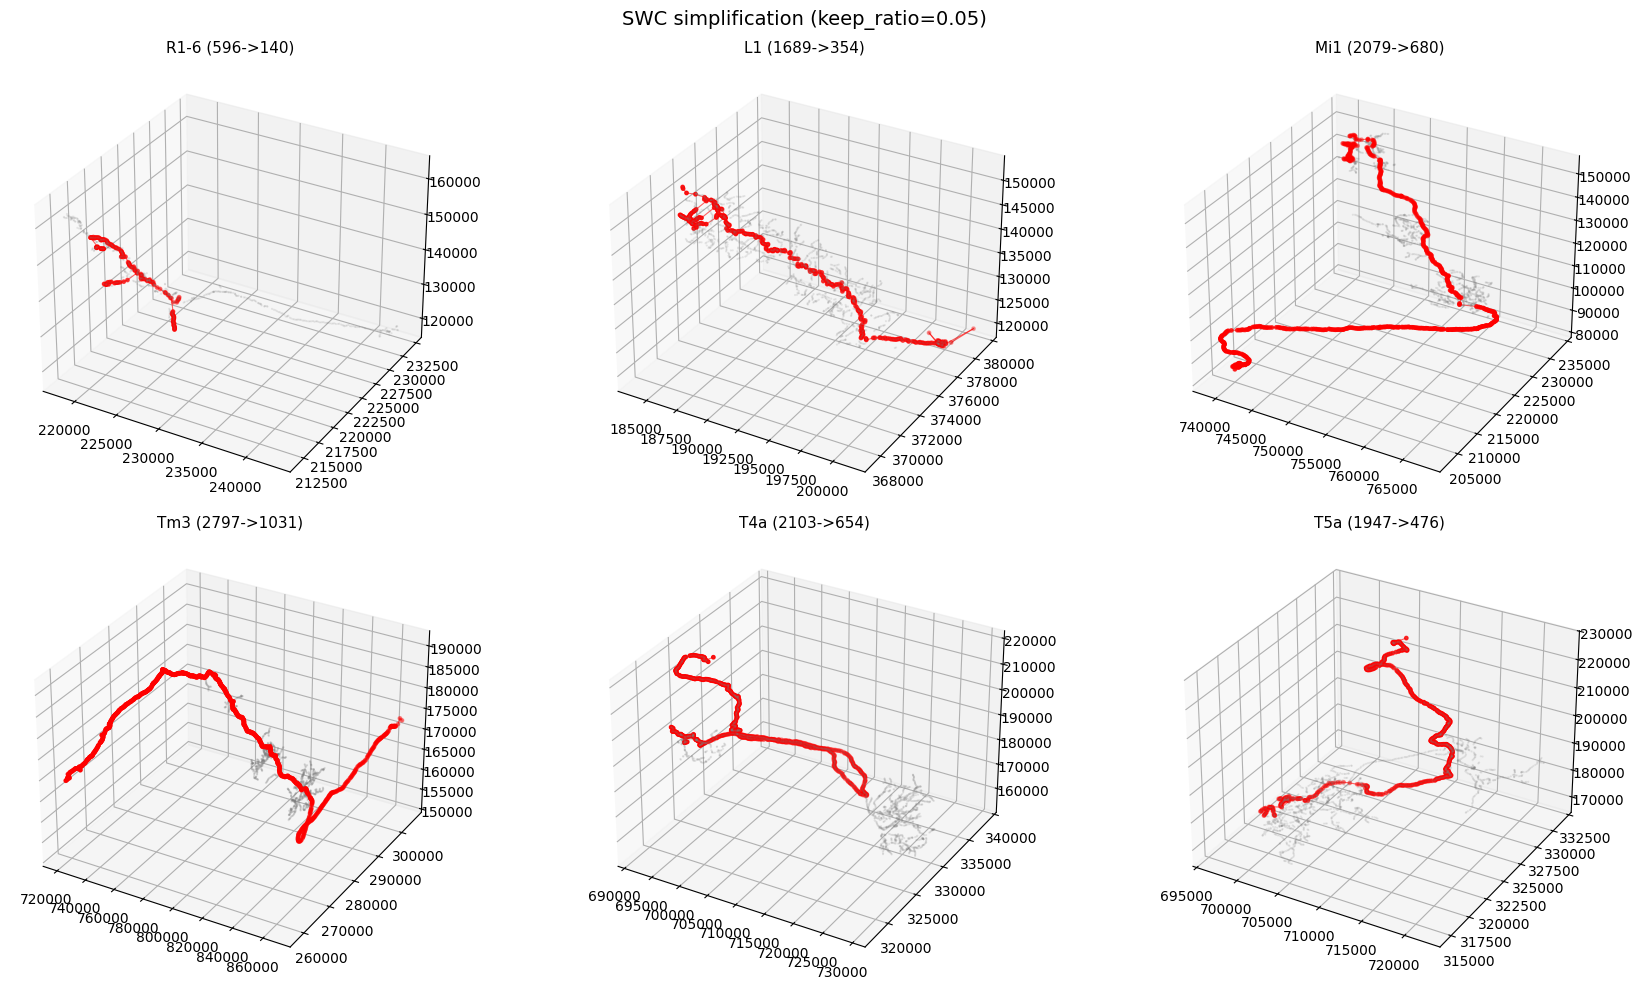

In [15]:
show_types = ['R1-6', 'L1', 'Mi1', 'Tm3', 'T4a', 'T5a']

fig = plt.figure(figsize=(18, 10))
for i, ct in enumerate(show_types):
    sample = vnt[(vnt['type'] == ct) & vnt['has_swc']]
    if len(sample) == 0:
        continue
    rid = sample['root_id'].iloc[0]

    txt = read_swc_text(rid, zf, zip_name_set, T4T5_DIR)
    if txt is None:
        continue
    with tempfile.NamedTemporaryFile(suffix='.swc', mode='w', delete=False) as tmp:
        tmp.write(txt); tp = tmp.name
    orig, _ = load_swc(tp)
    os.unlink(tp)

    simp_path = OUT_DIR / f'{rid}.swc'
    if simp_path.exists():
        simp, _ = load_swc(str(simp_path))
    else:
        simp, _, _ = simplify_one(txt, 0.5, COLLINEAR_ANGLE_DEG)

    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    ox = [n['x'] for n in orig.values()]
    oy = [n['y'] for n in orig.values()]
    oz = [n['z'] for n in orig.values()]
    ax.scatter(ox, oy, oz, s=0.3, alpha=0.15, c='gray')

    for nid, n in simp.items():
        if n['parent'] != -1 and n['parent'] in simp:
            p = simp[n['parent']]
            ax.plot([n['x'], p['x']], [n['y'], p['y']], [n['z'], p['z']],
                    'r-', lw=0.8, alpha=0.6)
    sx = [n['x'] for n in simp.values()]
    sy = [n['y'] for n in simp.values()]
    sz = [n['z'] for n in simp.values()]
    ax.scatter(sx, sy, sz, s=6, c='red')
    ax.set_title(f'{ct} ({len(orig)}->{len(simp)})', fontsize=11)

fig.suptitle(f'SWC simplification (keep_ratio={KEEP_RATIO})', fontsize=14)
plt.tight_layout(); plt.show()